# 🐝 PolliNexus v2

**Student**: Yilmaz Mustafa \
**Course**: Data Science \
**Assignment**: Plants for Bees Analysis \
**Date**: August 29, 2025 \
**GitHub**: https://github.com/codesapienbe/pollinexus

---

## 📖 Executive Summary

This analysis examines bee-plant interactions to determine optimal plant species for establishing pollinator-friendly habitats. Through comprehensive data analysis and machine learning techniques, we identify the top three plant species that best support native bee populations and provide strategic recommendations for habitat establishment.

**Key Improvements in v2:**
- Dynamic configuration and parameterization
- Better error handling and validation
- Modular analysis functions
- Adaptable to different datasets
- Improved code maintainability


## ⚙️ Configuration and Setup

Define all parameters and configuration settings in one place for easy modification.

In [42]:
# Configuration and Constants
from pathlib import Path
import os

# Project Configuration
CONFIG = {
    # Data settings
    'data_file': 'farm_data_for_publication.csv',
    'output_dir': Path.cwd() / 'outputs',
    
    # Analysis parameters
    'min_observations_threshold': 5,
    'top_n_plants': 3,
    'scoring_weights': {
        'native_bee_ratio': 0.4,
        'diversity': 0.3,
        'abundance': 0.3
    },
    
    # Visualization settings
    'figure_size': (12, 8),
    'color_palette': 'husl',
    'plot_style': 'seaborn-v0_8',
    
    # Model settings
    'random_state': 42,
    'test_size': 0.2,
    'cv_folds': 5
}

# Column mapping for different datasets
COLUMN_MAPPING = {
    'plant_species': 'plant species',
    'bee_species': 'Species',
    'season': 'season',
    'site': 'site',
    'plot_type': 'plot',
    'sampling_method': 'sampling',
    'date': 'date',
    'start_time': 'start time',
    'end_time': 'end time',
    'sex': 'Sex',
    'parasitic': 'parasitic',
    'nesting': 'nesting',
    'nonnative_bee': 'non-native bee'
}

# Create output directory
CONFIG['output_dir'].mkdir(exist_ok=True)

print("✅ Configuration loaded successfully")
print(f"📁 Output directory: {CONFIG['output_dir']}")
print(f"🔍 Analysis will focus on top {CONFIG['top_n_plants']} plants")

✅ Configuration loaded successfully
📁 Output directory: c:\Users\Administrator\Projects\pollinexus\notebooks\outputs
🔍 Analysis will focus on top 3 plants


## 🔧 Libraries and Helper Functions

Import required libraries and define reusable helper functions.

In [43]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
import logging
from datetime import datetime

warnings.filterwarnings('ignore')

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set visualization parameters
plt.style.use(CONFIG['plot_style'])
sns.set_palette(CONFIG['color_palette'])
plt.rcParams['figure.figsize'] = CONFIG['figure_size']

# Helper Functions
def load_and_validate_data(filepath):
    """
    Load data with validation and error handling.
    
    Parameters:
    -----------
    filepath : str or Path
        Path to the CSV file
        
    Returns:
    --------
    pandas.DataFrame or None
        Loaded and validated dataset
    """
    try:
        df = pd.read_csv(filepath)
        
        # Validate required columns
        required_cols = list(COLUMN_MAPPING.values())
        available_cols = set(df.columns)
        missing_cols = [col for col in required_cols if col not in available_cols]
        
        if missing_cols:
            logger.warning(f"Missing optional columns: {missing_cols}")
            
        # Basic data quality checks
        if df.empty:
            raise ValueError("Dataset is empty")
            
        logger.info(f"✅ Data loaded successfully: {df.shape}")
        return df
        
    except FileNotFoundError:
        logger.error(f"❌ File not found: {filepath}")
        return None
    except Exception as e:
        logger.error(f"❌ Error loading data: {str(e)}")
        return None

def create_binary_features(df, feature_mappings):
    """
    Create binary features based on mappings.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe
    feature_mappings : dict
        Mapping of new feature names to (source_col, condition) tuples
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with new binary features
    """
    df_copy = df.copy()
    
    for new_col, (source_col, condition) in feature_mappings.items():
        if source_col in df_copy.columns:
            if callable(condition):
                df_copy[new_col] = condition(df_copy[source_col]).astype(int)
            else:
                df_copy[new_col] = (df_copy[source_col] == condition).astype(int)
        else:
            logger.warning(f"Column {source_col} not found for feature {new_col}")
            df_copy[new_col] = 0
            
    return df_copy

def calculate_plant_score(ratio, diversity, abundance, weights=None):
    """
    Calculate comprehensive plant score using weighted metrics.
    
    Parameters:
    -----------
    ratio : float
        Native bee preference ratio
    diversity : float
        Bee species diversity score
    abundance : float
        Bee abundance score
    weights : dict, optional
        Scoring weights
        
    Returns:
    --------
    float
        Composite plant score
    """
    if weights is None:
        weights = CONFIG['scoring_weights']
        
    return (ratio * weights['native_bee_ratio'] + 
            diversity * weights['diversity'] + 
            abundance * weights['abundance'])

print("✅ Libraries imported successfully")
print("📊 Visualization settings configured")
print("🔧 Helper functions defined")

✅ Libraries imported successfully
📊 Visualization settings configured
🔧 Helper functions defined


## 📊 Data Loading and Exploration

Load the dataset and perform initial exploration.

In [44]:
# Load and validate data
df = load_and_validate_data(CONFIG['data_file'])

if df is None:
    raise ValueError("Failed to load data. Please check the file path and format.")

print("=" * 50)
print("🐝 FARM DATA DATASET OVERVIEW")
print("=" * 50)
print(f"📊 Dataset shape: {df.shape}")
print(f"🔍 Columns ({len(df.columns)}): {df.columns.tolist()[:10]}...")

print("\n📋 First 5 rows of key columns:")
key_cols = [COLUMN_MAPPING['plant_species'], COLUMN_MAPPING['bee_species'], 
           COLUMN_MAPPING['plot_type'], COLUMN_MAPPING['season']]
available_key_cols = [col for col in key_cols if col in df.columns]
display(df[available_key_cols].head())

print("\n📊 Basic statistics:")
display(df.describe())

print("\n❌ Missing values analysis:")
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
if len(missing_data) > 0:
    missing_df = pd.DataFrame({
        'Missing Count': missing_data,
        'Percentage': (missing_data / len(df) * 100).round(2)
    })
    display(missing_df.head(10))
else:
    print("No missing values found!")

2025-08-29 13:38:53,043 - INFO - ✅ Data loaded successfully: (3744, 77)


🐝 FARM DATA DATASET OVERVIEW
📊 Dataset shape: (3744, 77)
🔍 Columns (77): ['ID', 'Sample', 'no of specimens in sample', 'date', 'year', 'season', 'site', 'plot', 'site_plot', 'site_plot_year']...

📋 First 5 rows of key columns:


,plant species,Species,plot,season
0,Trifolium repens,Bombus,non-native,late.season
1,Cosmos bipinnatus,Bombus,non-native,late.season
2,Cosmos bipinnatus,Bombus,non-native,late.season
3,Monarda punctata,large green bee,native,late.season
4,Monarda punctata,large green bee,native,late.season



📊 Basic statistics:


,Sample,no of specimens in sample,year,vegetation cover,height of vegetation (cm),Achillea millefolium,Agastache foeniculum,Calendula officinalis,Leucanthemum vulgare,Leucanthemum maximum,...,Solidago nemoralis,Symphyotrichum laeve,Tradescantia virginiana,Verbena hastata,no bee,lrg green bee,only genus level,bee specialist,parasitic,non-native bee
count,3023.000000,3023.000000,3744.000000,2397.000000,2549.000000,2549.0,2549.000000,2549.0,2549.000000,2549.000000,...,2549.000000,2549.000000,2549.000000,2549.0,0.0,0.0,3673.000000,3579.000000,3579.000000,3580.000000
mean,16899.143235,19.893483,2016.680823,83.102837,129.548843,0.0,0.061200,0.0,0.214986,0.015300,...,0.026285,0.149078,0.045508,0.0,NaN,NaN,0.412469,0.006985,0.034367,0.155866
std,720.582420,12.683357,0.466220,19.364555,49.584938,0.0,0.239745,0.0,0.410893,0.122768,...,0.160012,0.356235,0.208456,0.0,NaN,NaN,3.710966,0.083297,0.182196,0.362779
min,15902.000000,1.000000,2016.000000,30.000000,10.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,16030.000000,10.000000,2016.000000,80.000000,120.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,NaN,NaN,0.000000,0.000000,0.000000,0.000000
50%,17423.000000,18.000000,2017.000000,90.000000,150.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,NaN,NaN,0.000000,0.000000,0.000000,0.000000
75%,17469.000000,28.000000,2017.000000,97.500000,160.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,NaN,NaN,0.000000,0.000000,0.000000,0.000000
max,17548.000000,63.000000,2017.000000,100.000000,220.000000,0.0,1.000000,0.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.0,NaN,NaN,53.000000,1.000000,1.000000,1.000000



❌ Missing values analysis:


,Missing Count,Percentage
no bee,3744,100.00
lrg green bee,3744,100.00
small dark bee,3735,99.76
Anthidium,3728,99.57
specialized on,3719,99.33
bumble bee,3718,99.31
status,3718,99.31
Megachile,3708,99.04
small green metallic bee,3634,97.06
lrg carpenter bee,3531,94.31


## 🔄 Data Preprocessing

Clean and prepare the data for analysis.

In [45]:
def preprocess_data(df):
    """
    Clean and prepare data for analysis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Raw input dataframe
        
    Returns:
    --------
    pandas.DataFrame
        Cleaned and processed dataframe
    """
    df_clean = df.copy()
    
    # Handle missing values in plant species (treat as 'Air_Sampling' for consistency)
    plant_col = COLUMN_MAPPING['plant_species']
    if plant_col in df_clean.columns:
        df_clean[plant_col] = df_clean[plant_col].fillna('Air_Sampling')
    
    # Handle missing values in other key columns
    if COLUMN_MAPPING['parasitic'] in df_clean.columns:
        df_clean[COLUMN_MAPPING['parasitic']] = df_clean[COLUMN_MAPPING['parasitic']].fillna(0)
    
    if COLUMN_MAPPING['nonnative_bee'] in df_clean.columns:
        df_clean[COLUMN_MAPPING['nonnative_bee']] = df_clean[COLUMN_MAPPING['nonnative_bee']].fillna(0)
    
    # Create time of day categories if time columns exist
    if COLUMN_MAPPING['start_time'] in df_clean.columns:
        # Convert time to numeric if it's not already
        def parse_time(time_val):
            if pd.isna(time_val):
                return np.nan
            try:
                if isinstance(time_val, str):
                    # Handle different time formats
                    if ':' in str(time_val):
                        time_parts = str(time_val).split(':')
                        return int(time_parts[0]) * 100 + int(time_parts[1])
                    else:
                        return int(time_val)
                else:
                    return int(time_val)
            except:
                return np.nan
        
        df_clean['time_numeric'] = df_clean[COLUMN_MAPPING['start_time']].apply(parse_time)
        
        # Create time of day categories
        def categorize_time(time_val):
            if pd.isna(time_val):
                return 'Unknown'
            elif time_val < 1000:
                return 'Morning'
            elif time_val < 1400:
                return 'Midday'
            else:
                return 'Afternoon'
        
        df_clean['time_of_day'] = df_clean['time_numeric'].apply(categorize_time)
    
    # Create binary features using our helper function
    binary_features = {}
    
    # Native bee indicator (1 if native, 0 if non-native)
    if COLUMN_MAPPING['nonnative_bee'] in df_clean.columns:
        binary_features['native_bee'] = (COLUMN_MAPPING['nonnative_bee'], lambda x: x == 0)
    
    # Native plot indicator
    if COLUMN_MAPPING['plot_type'] in df_clean.columns:
        binary_features['is_native_plot'] = (COLUMN_MAPPING['plot_type'], 'native')
    
    # Early season indicator
    if COLUMN_MAPPING['season'] in df_clean.columns:
        binary_features['is_early_season'] = (COLUMN_MAPPING['season'], 'early.season')
    
    # Apply binary feature creation
    if binary_features:
        df_clean = create_binary_features(df_clean, binary_features)
    
    # Remove rows with missing bee species as this is critical for analysis
    if COLUMN_MAPPING['bee_species'] in df_clean.columns:
        initial_count = len(df_clean)
        df_clean = df_clean.dropna(subset=[COLUMN_MAPPING['bee_species']])
        removed_count = initial_count - len(df_clean)
        if removed_count > 0:
            logger.info(f"Removed {removed_count} rows with missing bee species")
    
    logger.info(f"Data preprocessing completed. Final shape: {df_clean.shape}")
    return df_clean

# Apply preprocessing
df_processed = preprocess_data(df)

print("\n🔄 Data preprocessing completed!")
print(f"📊 Processed dataset shape: {df_processed.shape}")

# Show sample of processed data
print("\n📋 Sample of processed data:")
sample_cols = [COLUMN_MAPPING['plant_species'], COLUMN_MAPPING['bee_species']]
if 'native_bee' in df_processed.columns:
    sample_cols.append('native_bee')
if 'time_of_day' in df_processed.columns:
    sample_cols.append('time_of_day')
if COLUMN_MAPPING['season'] in df_processed.columns:
    sample_cols.append(COLUMN_MAPPING['season'])

available_sample_cols = [col for col in sample_cols if col in df_processed.columns]
display(df_processed[available_sample_cols].head())

2025-08-29 13:51:29,008 - INFO - Removed 17 rows with missing bee species
2025-08-29 13:51:29,009 - INFO - Data preprocessing completed. Final shape: (3727, 82)



🔄 Data preprocessing completed!
📊 Processed dataset shape: (3727, 82)

📋 Sample of processed data:


,plant species,Species,native_bee,time_of_day,season
0,Trifolium repens,Bombus,1,Midday,late.season
1,Cosmos bipinnatus,Bombus,1,Midday,late.season
2,Cosmos bipinnatus,Bombus,1,Afternoon,late.season
3,Monarda punctata,large green bee,1,Afternoon,late.season
4,Monarda punctata,large green bee,1,Afternoon,late.season


## 📈 Exploratory Data Analysis

Analyze the distribution and relationships in the data.

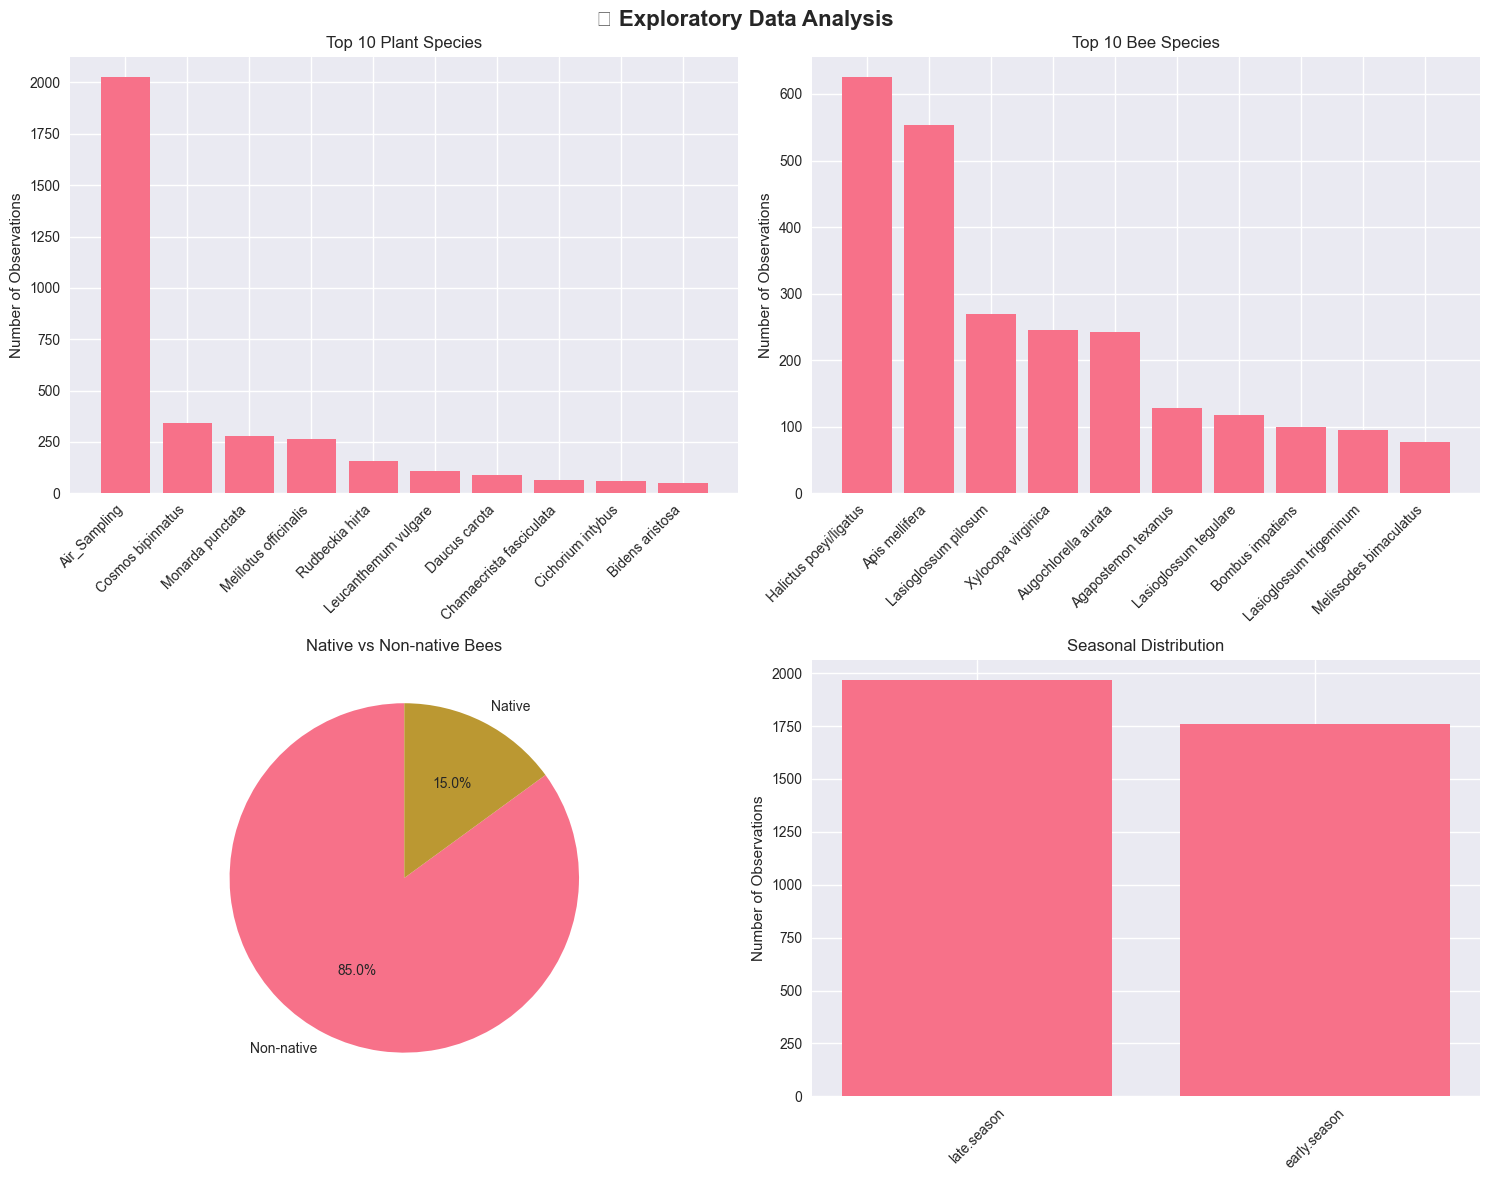


📊 Key Statistics:
🌸 Total plant species: 32
🐝 Total bee species: 131
📅 Date range: 04/18/2017 to 10/03/2017
🏠 Native bees: 85.0% of observations


In [46]:
def perform_eda(df):
    """
    Perform comprehensive exploratory data analysis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Processed dataframe
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('🔍 Exploratory Data Analysis', fontsize=16, fontweight='bold')
    
    # 1. Plant species distribution
    plant_col = COLUMN_MAPPING['plant_species']
    if plant_col in df.columns:
        plant_counts = df[plant_col].value_counts().head(10)
        axes[0, 0].bar(range(len(plant_counts)), plant_counts.values)
        axes[0, 0].set_title('Top 10 Plant Species')
        axes[0, 0].set_ylabel('Number of Observations')
        axes[0, 0].set_xticks(range(len(plant_counts)))
        axes[0, 0].set_xticklabels(plant_counts.index, rotation=45, ha='right')
    
    # 2. Bee species distribution
    bee_col = COLUMN_MAPPING['bee_species']
    if bee_col in df.columns:
        bee_counts = df[bee_col].value_counts().head(10)
        axes[0, 1].bar(range(len(bee_counts)), bee_counts.values)
        axes[0, 1].set_title('Top 10 Bee Species')
        axes[0, 1].set_ylabel('Number of Observations')
        axes[0, 1].set_xticks(range(len(bee_counts)))
        axes[0, 1].set_xticklabels(bee_counts.index, rotation=45, ha='right')
    
    # 3. Native vs Non-native distribution
    if 'native_bee' in df.columns:
        native_counts = df['native_bee'].value_counts()
        labels = ['Non-native', 'Native']
        axes[1, 0].pie(native_counts.values, labels=labels, autopct='%1.1f%%', startangle=90)
        axes[1, 0].set_title('Native vs Non-native Bees')
    
    # 4. Seasonal distribution
    season_col = COLUMN_MAPPING['season']
    if season_col in df.columns:
        season_counts = df[season_col].value_counts()
        axes[1, 1].bar(season_counts.index, season_counts.values)
        axes[1, 1].set_title('Seasonal Distribution')
        axes[1, 1].set_ylabel('Number of Observations')
        axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] / 'eda_overview.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary statistics
    print("\n📊 Key Statistics:")
    print(f"🌸 Total plant species: {df[plant_col].nunique() if plant_col in df.columns else 'Unknown'}")
    print(f"🐝 Total bee species: {df[bee_col].nunique() if bee_col in df.columns else 'Unknown'}")
    print(f"📅 Date range: {df[COLUMN_MAPPING['date']].min()} to {df[COLUMN_MAPPING['date']].max() if COLUMN_MAPPING['date'] in df.columns else 'Unknown'}")
    
    if 'native_bee' in df.columns:
        native_percentage = (df['native_bee'].sum() / len(df)) * 100
        print(f"🏠 Native bees: {native_percentage:.1f}% of observations")

# Perform EDA
perform_eda(df_processed)

## 🌱 Plant-Bee Interaction Analysis

Analyze which plants attract the most native bees and create scoring system.

In [47]:
class PlantBeeAnalyzer:
    """
    Comprehensive plant-bee interaction analyzer.
    """
    
    def __init__(self, config=None):
        self.config = config or CONFIG
        self.plant_scores = None
        
    def analyze_plant_preferences(self, df):
        """
        Analyze plant preferences for native bees.
        
        Parameters:
        -----------
        df : pandas.DataFrame
            Clean dataset with bee-plant interactions
            
        Returns:
        --------
        pandas.DataFrame
            Plant analysis results with scores and recommendations
        """
        logger.info(f"Starting plant preference analysis with {len(df)} observations")
        
        plant_col = COLUMN_MAPPING['plant_species']
        bee_col = COLUMN_MAPPING['bee_species']
        
        # Filter out air sampling and plants with insufficient data
        df_analysis = df[df[plant_col] != 'Air_Sampling'].copy()
        
        # Group by plant species and calculate metrics
        plant_stats = df_analysis.groupby(plant_col).agg({
            'native_bee': ['count', 'sum', 'mean'] if 'native_bee' in df_analysis.columns else ['count'],
            bee_col: 'nunique'
        }).round(3)
        
        # Flatten column names
        plant_stats.columns = ['_'.join(col).strip() for col in plant_stats.columns.values]
        
        # Rename columns for clarity
        column_mapping = {
            'native_bee_count': 'total_observations',
            'native_bee_sum': 'native_bee_count',
            'native_bee_mean': 'native_bee_ratio',
            f'{bee_col}_nunique': 'bee_species_diversity'
        }
        
        # Apply column renaming for available columns
        available_renames = {old: new for old, new in column_mapping.items() if old in plant_stats.columns}
        plant_stats = plant_stats.rename(columns=available_renames)
        
        # Filter plants with sufficient observations
        min_obs = self.config['min_observations_threshold']
        plant_stats = plant_stats[plant_stats['total_observations'] >= min_obs]
        
        if len(plant_stats) == 0:
            logger.warning(f"No plants found with >= {min_obs} observations")
            return pd.DataFrame()
        
        # Calculate normalized scores (0-1 scale)
        if 'native_bee_ratio' in plant_stats.columns:
            plant_stats['native_bee_ratio_norm'] = plant_stats['native_bee_ratio']
        else:
            plant_stats['native_bee_ratio_norm'] = 0.5  # Default neutral score
            
        plant_stats['diversity_score_norm'] = (
            (plant_stats['bee_species_diversity'] - plant_stats['bee_species_diversity'].min()) /
            (plant_stats['bee_species_diversity'].max() - plant_stats['bee_species_diversity'].min())
        ).fillna(0)
        
        plant_stats['abundance_score_norm'] = (
            (plant_stats['total_observations'] - plant_stats['total_observations'].min()) /
            (plant_stats['total_observations'].max() - plant_stats['total_observations'].min())
        ).fillna(0)
        
        # Calculate composite score
        plant_stats['composite_score'] = plant_stats.apply(
            lambda row: calculate_plant_score(
                row['native_bee_ratio_norm'],
                row['diversity_score_norm'],
                row['abundance_score_norm']
            ), axis=1
        )
        
        # Sort by composite score
        plant_stats = plant_stats.sort_values('composite_score', ascending=False)
        
        self.plant_scores = plant_stats
        logger.info(f"Plant analysis completed for {len(plant_stats)} plant species")
        
        return plant_stats
    
    def get_top_recommendations(self, n=None):
        """
        Get top N plant recommendations.
        
        Parameters:
        -----------
        n : int, optional
            Number of top plants to return. Uses config default if None.
            
        Returns:
        --------
        pandas.DataFrame
            Top recommended plants
        """
        if self.plant_scores is None:
            raise ValueError("Run analyze_plant_preferences first")
            
        if n is None:
            n = self.config['top_n_plants']
            
        return self.plant_scores.head(n)

# Initialize analyzer and run analysis
analyzer = PlantBeeAnalyzer()
plant_results = analyzer.analyze_plant_preferences(df_processed)

if len(plant_results) > 0:
    print("\n🌱 Plant Analysis Results:")
    print("=" * 60)
    display(plant_results.head(10))
    
    # Get top recommendations
    top_plants = analyzer.get_top_recommendations()
    print(f"\n🏆 Top {CONFIG['top_n_plants']} Recommended Plants:")
    print("=" * 40)
    for i, (plant, row) in enumerate(top_plants.iterrows(), 1):
        print(f"{i}. {plant}")
        print(f"   📊 Composite Score: {row['composite_score']:.3f}")
        if 'native_bee_ratio' in row:
            print(f"   🏠 Native Bee Ratio: {row['native_bee_ratio']:.3f}")
        print(f"   🐝 Bee Diversity: {row['bee_species_diversity']} species")
        print(f"   📈 Total Observations: {row['total_observations']}")
        print()
        
    # Save results
    plant_results.to_csv(CONFIG['output_dir'] / 'plant_analysis_results.csv')
    print(f"💾 Results saved to: {CONFIG['output_dir'] / 'plant_analysis_results.csv'}")
else:
    print("⚠️ No plants found with sufficient observations for analysis")

2025-08-29 14:09:34,713 - INFO - Starting plant preference analysis with 3727 observations
2025-08-29 14:09:34,739 - INFO - Plant analysis completed for 25 plant species



🌱 Plant Analysis Results:


,total_observations,native_bee_count,native_bee_ratio,bee_species_diversity,native_bee_ratio_norm,diversity_score_norm,abundance_score_norm,composite_score
plant species,,,,,,,,
Cosmos bipinnatus,340,256,0.753,38,0.753,1.000000,1.000000,0.901200
Rudbeckia hirta,159,158,0.994,23,0.994,0.571429,0.459701,0.706939
Monarda punctata,279,244,0.875,15,0.875,0.342857,0.817910,0.698230
Leucanthemum vulgare,107,105,0.981,20,0.981,0.485714,0.304478,0.629458
Rudbeckia triloba,43,42,0.977,18,0.977,0.428571,0.113433,0.553401
Cichorium intybus,59,53,0.898,20,0.898,0.485714,0.161194,0.553272
Daucus carota,89,60,0.674,23,0.674,0.571429,0.250746,0.516252
Helenium flexuosum,34,34,1.000,11,1.000,0.228571,0.086567,0.494542
Lobularia maritima,15,15,1.000,12,1.000,0.257143,0.029851,0.486098



🏆 Top 3 Recommended Plants:
1. Cosmos bipinnatus
   📊 Composite Score: 0.901
   🏠 Native Bee Ratio: 0.753
   🐝 Bee Diversity: 38.0 species
   📈 Total Observations: 340.0

2. Rudbeckia hirta
   📊 Composite Score: 0.707
   🏠 Native Bee Ratio: 0.994
   🐝 Bee Diversity: 23.0 species
   📈 Total Observations: 159.0

3. Monarda punctata
   📊 Composite Score: 0.698
   🏠 Native Bee Ratio: 0.875
   🐝 Bee Diversity: 15.0 species
   📈 Total Observations: 279.0

💾 Results saved to: c:\Users\Administrator\Projects\pollinexus\notebooks\outputs\plant_analysis_results.csv


## 🤖 Machine Learning Analysis

Use machine learning to identify the most important factors in native bee attraction.

2025-08-29 14:16:35,056 - INFO - Starting machine learning analysis
2025-08-29 14:16:35,111 - INFO - Training model with 3727 samples and 6 features


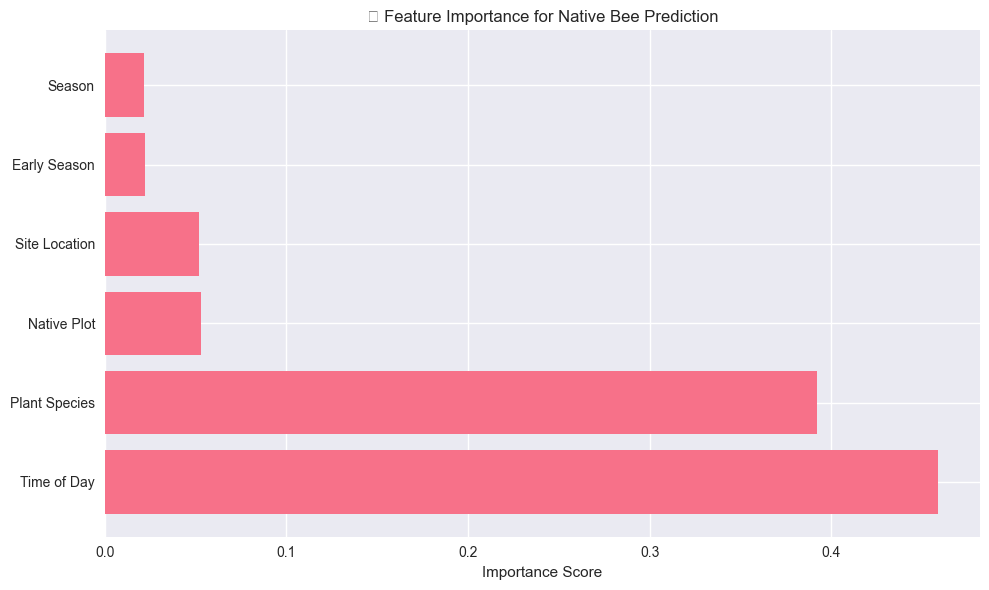

2025-08-29 14:16:36,522 - INFO - ML analysis completed. Accuracy: 0.922



🤖 Machine Learning Results:
🎯 Model Accuracy: 0.922

📊 Feature Importance:


,feature_readable,importance
5,Time of Day,0.458971
0,Plant Species,0.392431
3,Native Plot,0.053041
2,Site Location,0.051937
4,Early Season,0.022172
1,Season,0.021448



📋 Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.59      0.69       112
           1       0.93      0.98      0.96       634

    accuracy                           0.92       746
   macro avg       0.89      0.79      0.83       746
weighted avg       0.92      0.92      0.92       746


💾 ML results saved to: c:\Users\Administrator\Projects\pollinexus\notebooks\outputs


In [48]:
def perform_ml_analysis(df):
    """
    Perform machine learning analysis to identify key factors for native bee attraction.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Processed dataframe
        
    Returns:
    --------
    dict
        ML analysis results including model performance and feature importance
    """
    if 'native_bee' not in df.columns:
        logger.warning("Native bee column not available. Skipping ML analysis.")
        return None
    
    logger.info("Starting machine learning analysis")
    
    # Prepare features for ML
    ml_df = df.copy()
    
    # Encode categorical variables
    le_plant = LabelEncoder()
    le_season = LabelEncoder()
    le_site = LabelEncoder()
    
    # Encode plant species
    plant_col = COLUMN_MAPPING['plant_species']
    if plant_col in ml_df.columns:
        ml_df['plant_encoded'] = le_plant.fit_transform(ml_df[plant_col].astype(str))
    
    # Encode season
    season_col = COLUMN_MAPPING['season']
    if season_col in ml_df.columns:
        ml_df['season_encoded'] = le_season.fit_transform(ml_df[season_col].astype(str))
    
    # Encode site
    site_col = COLUMN_MAPPING['site']
    if site_col in ml_df.columns:
        ml_df['site_encoded'] = le_site.fit_transform(ml_df[site_col].astype(str))
    
    # Select features for the model
    feature_cols = ['plant_encoded']
    
    # Add available features
    optional_features = ['season_encoded', 'site_encoded', 'is_native_plot', 'is_early_season']
    for col in optional_features:
        if col in ml_df.columns:
            feature_cols.append(col)
    
    # Add time feature if available
    if 'time_numeric' in ml_df.columns:
        ml_df['time_encoded'] = ml_df['time_numeric'].fillna(ml_df['time_numeric'].median())
        feature_cols.append('time_encoded')
    
    # Remove rows with missing target variable
    ml_df = ml_df.dropna(subset=['native_bee'])
    
    if len(ml_df) == 0:
        logger.error("No valid data for ML analysis")
        return None
    
    # Prepare X and y
    X = ml_df[feature_cols]
    y = ml_df['native_bee']
    
    logger.info(f"Training model with {len(X)} samples and {len(feature_cols)} features")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=CONFIG['test_size'], random_state=CONFIG['random_state'], stratify=y
    )
    
    # Train Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=CONFIG['random_state'],
        n_jobs=-1
    )
    
    rf_model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = rf_model.predict(X_test)
    
    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Create readable feature names
    feature_name_mapping = {
        'plant_encoded': 'Plant Species',
        'season_encoded': 'Season',
        'site_encoded': 'Site Location',
        'is_native_plot': 'Native Plot',
        'is_early_season': 'Early Season',
        'time_encoded': 'Time of Day'
    }
    
    feature_importance['feature_readable'] = feature_importance['feature'].map(
        lambda x: feature_name_mapping.get(x, x)
    )
    
    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature_readable'], feature_importance['importance'])
    plt.title('🎯 Feature Importance for Native Bee Prediction')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] / 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    results = {
        'model': rf_model,
        'accuracy': accuracy,
        'feature_importance': feature_importance,
        'classification_report': classification_report(y_test, y_pred),
        'encoders': {
            'plant': le_plant,
            'season': le_season if season_col in ml_df.columns else None,
            'site': le_site if site_col in ml_df.columns else None
        }
    }
    
    logger.info(f"ML analysis completed. Accuracy: {accuracy:.3f}")
    return results

# Perform ML analysis
ml_results = perform_ml_analysis(df_processed)

if ml_results:
    print("\n🤖 Machine Learning Results:")
    print("=" * 40)
    print(f"🎯 Model Accuracy: {ml_results['accuracy']:.3f}")
    print("\n📊 Feature Importance:")
    display(ml_results['feature_importance'][['feature_readable', 'importance']])
    
    print("\n📋 Classification Report:")
    print(ml_results['classification_report'])
    
    # Save ML results
    ml_results['feature_importance'].to_csv(
        CONFIG['output_dir'] / 'feature_importance.csv', index=False
    )
    print(f"\n💾 ML results saved to: {CONFIG['output_dir']}")
else:
    print("⚠️ Machine learning analysis could not be performed")

## 📊 Comprehensive Visualization

Create comprehensive visualizations of the analysis results.

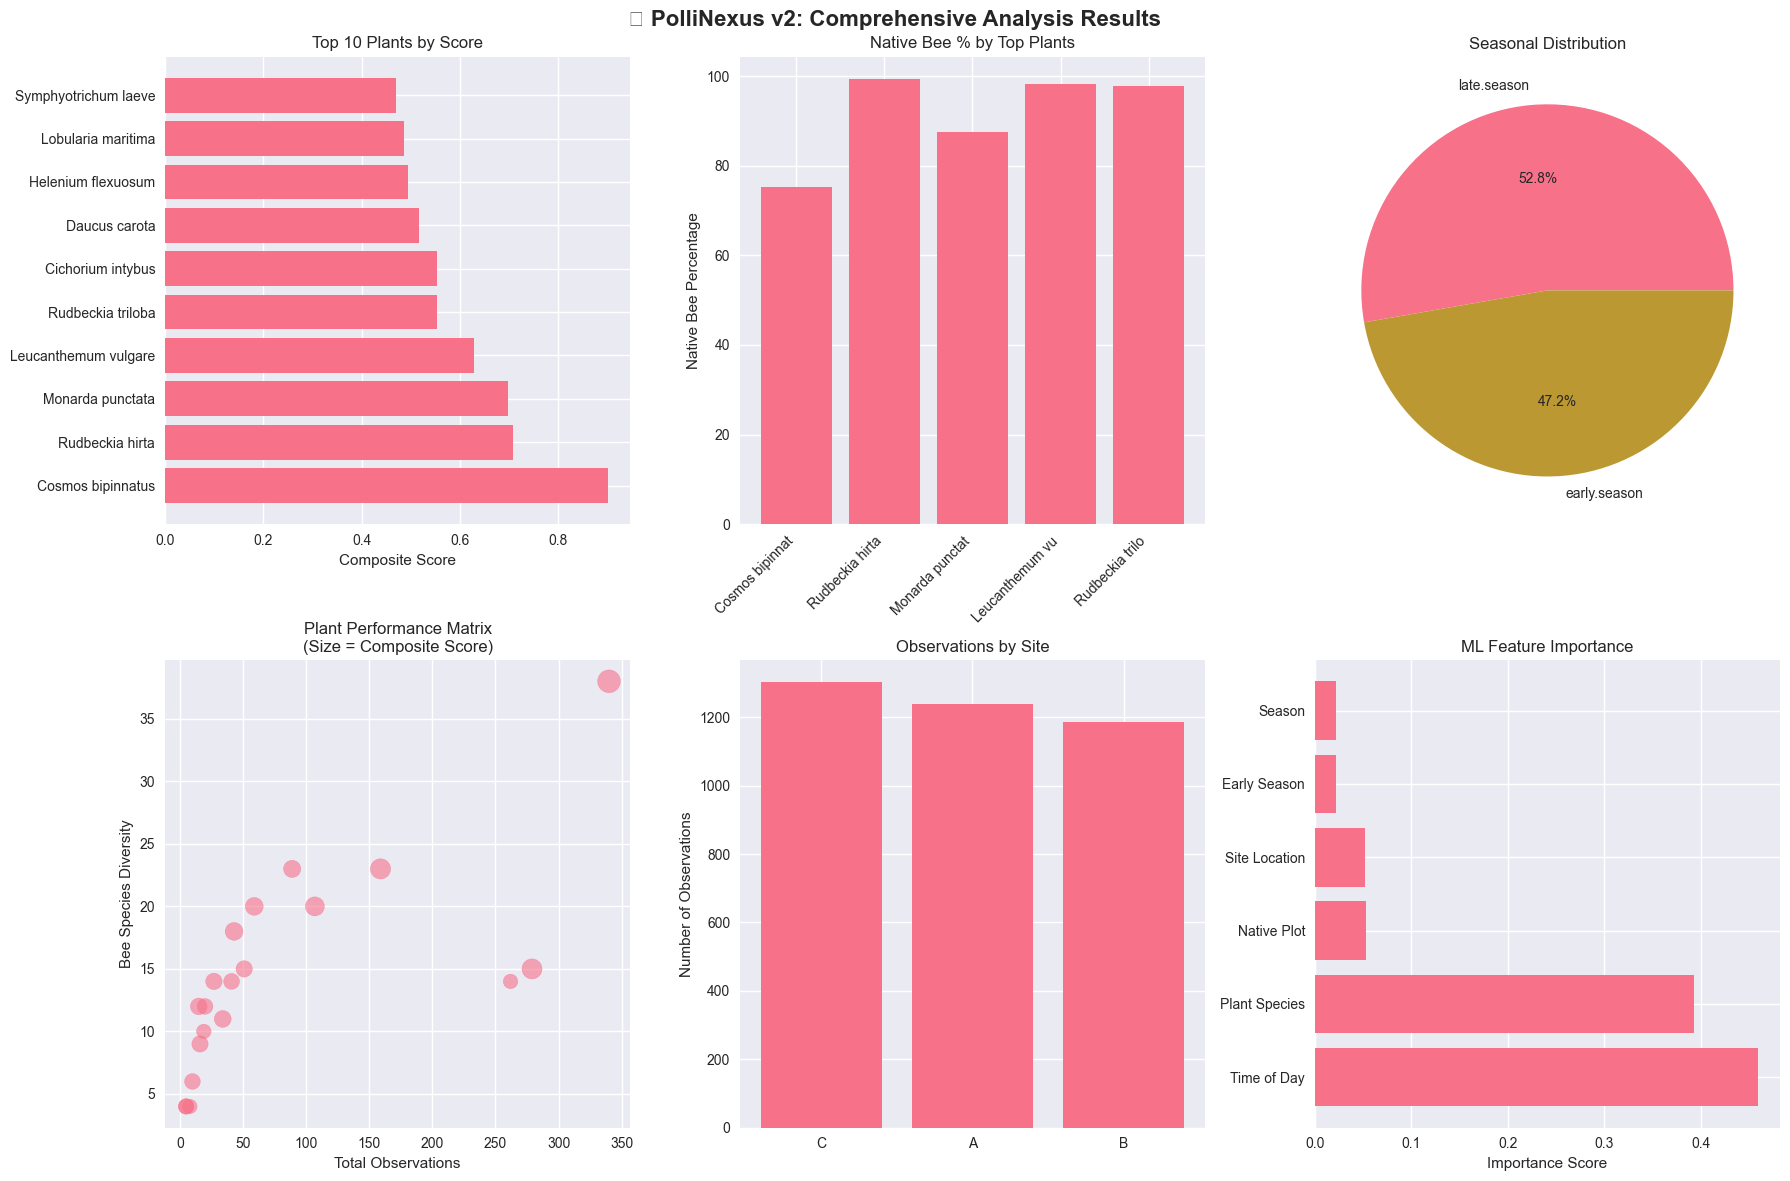


📊 Comprehensive visualizations saved to: c:\Users\Administrator\Projects\pollinexus\notebooks\outputs


In [49]:
def create_comprehensive_visualizations(df, plant_results, ml_results=None):
    """
    Create comprehensive visualizations of the analysis results.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Processed dataframe
    plant_results : pandas.DataFrame
        Plant analysis results
    ml_results : dict, optional
        Machine learning results
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('🌟 PolliNexus v2: Comprehensive Analysis Results', fontsize=16, fontweight='bold')
    
    # 1. Top Plants by Composite Score
    if len(plant_results) > 0:
        top_10_plants = plant_results.head(10)
        axes[0, 0].barh(range(len(top_10_plants)), top_10_plants['composite_score'])
        axes[0, 0].set_yticks(range(len(top_10_plants)))
        axes[0, 0].set_yticklabels([name[:20] + '...' if len(name) > 20 else name 
                                   for name in top_10_plants.index])
        axes[0, 0].set_title('Top 10 Plants by Score')
        axes[0, 0].set_xlabel('Composite Score')
    
    # 2. Native vs Non-native Bee Distribution by Plant
    if 'native_bee' in df.columns and len(plant_results) > 0:
        plant_col = COLUMN_MAPPING['plant_species']
        top_5_plants = plant_results.head(5).index
        plant_native_data = []
        
        for plant in top_5_plants:
            plant_df = df[df[plant_col] == plant]
            if len(plant_df) > 0:
                native_pct = plant_df['native_bee'].mean() * 100
                plant_native_data.append((plant[:15], native_pct))
        
        if plant_native_data:
            plants, native_pcts = zip(*plant_native_data)
            axes[0, 1].bar(range(len(plants)), native_pcts)
            axes[0, 1].set_xticks(range(len(plants)))
            axes[0, 1].set_xticklabels(plants, rotation=45, ha='right')
            axes[0, 1].set_title('Native Bee % by Top Plants')
            axes[0, 1].set_ylabel('Native Bee Percentage')
    
    # 3. Seasonal Distribution of Observations
    season_col = COLUMN_MAPPING['season']
    if season_col in df.columns:
        season_counts = df[season_col].value_counts()
        axes[0, 2].pie(season_counts.values, labels=season_counts.index, autopct='%1.1f%%')
        axes[0, 2].set_title('Seasonal Distribution')
    
    # 4. Plant Diversity vs Abundance
    if len(plant_results) > 0 and 'bee_species_diversity' in plant_results.columns:
        scatter_data = plant_results.head(20)  # Top 20 for clarity
        axes[1, 0].scatter(scatter_data['total_observations'], 
                          scatter_data['bee_species_diversity'],
                          s=scatter_data['composite_score'] * 300,
                          alpha=0.6)
        axes[1, 0].set_xlabel('Total Observations')
        axes[1, 0].set_ylabel('Bee Species Diversity')
        axes[1, 0].set_title('Plant Performance Matrix\n(Size = Composite Score)')
    
    # 5. Site Distribution
    site_col = COLUMN_MAPPING['site']
    if site_col in df.columns:
        site_counts = df[site_col].value_counts()
        axes[1, 1].bar(site_counts.index, site_counts.values)
        axes[1, 1].set_title('Observations by Site')
        axes[1, 1].set_ylabel('Number of Observations')
    
    # 6. Feature Importance (if available)
    if ml_results and 'feature_importance' in ml_results:
        importance_data = ml_results['feature_importance'].head(6)
        axes[1, 2].barh(range(len(importance_data)), importance_data['importance'])
        axes[1, 2].set_yticks(range(len(importance_data)))
        axes[1, 2].set_yticklabels(importance_data['feature_readable'])
        axes[1, 2].set_title('ML Feature Importance')
        axes[1, 2].set_xlabel('Importance Score')
    else:
        # Alternative: Show plot type distribution
        plot_col = COLUMN_MAPPING['plot_type']
        if plot_col in df.columns:
            plot_counts = df[plot_col].value_counts()
            axes[1, 2].bar(plot_counts.index, plot_counts.values)
            axes[1, 2].set_title('Plot Type Distribution')
            axes[1, 2].set_ylabel('Number of Observations')
    
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] / 'comprehensive_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create visualizations
if len(plant_results) > 0:
    create_comprehensive_visualizations(df_processed, plant_results, ml_results)
    print(f"\n📊 Comprehensive visualizations saved to: {CONFIG['output_dir']}")
else:
    print("⚠️ Cannot create visualizations without plant analysis results")

## 📋 Final Summary and Recommendations

Provide final recommendations based on the comprehensive analysis.

In [50]:
from datetime import datetime
import json
from pathlib import Path

def serialize_for_json(obj):
    """
    Helper function to convert non-serializable objects (e.g., Path) to strings for JSON export.
    """
    if isinstance(obj, Path):
        return str(obj)
    # Add more custom conversions here if needed
    return obj

def make_config_json_serializable(config):
    """
    Recursively convert all Path objects in the config dict to strings.
    """
    if isinstance(config, dict):
        return {k: make_config_json_serializable(v) for k, v in config.items()}
    elif isinstance(config, list):
        return [make_config_json_serializable(v) for v in config]
    elif isinstance(config, Path):
        return str(config)
    else:
        return config

def generate_final_recommendations(plant_results, ml_results=None):
    """
    Generate final recommendations based on analysis results.

    Parameters:
    -----------
    plant_results : pandas.DataFrame
        Plant analysis results
    ml_results : dict, optional
        Machine learning results

    Returns:
    --------
    dict
        Final recommendations and insights
    """
    recommendations = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'analysis_config': make_config_json_serializable(CONFIG),
        'top_plants': [],
        'key_insights': [],
        'implementation_recommendations': []
    }

    if len(plant_results) > 0:
        # Get top plants
        top_plants = plant_results.head(CONFIG['top_n_plants'])

        for i, (plant, row) in enumerate(top_plants.iterrows(), 1):
            plant_info = {
                'rank': i,
                'name': plant,
                'composite_score': round(row['composite_score'], 3),
                'total_observations': int(row['total_observations']),
                'bee_species_diversity': int(row['bee_species_diversity'])
            }

            if 'native_bee_ratio' in row:
                plant_info['native_bee_ratio'] = round(row['native_bee_ratio'], 3)

            recommendations['top_plants'].append(plant_info)

    # Key insights
    if len(plant_results) > 0:
        total_plants_analyzed = len(plant_results)
        avg_score = plant_results['composite_score'].mean()

        recommendations['key_insights'].extend([
            f"Analyzed {total_plants_analyzed} plant species with sufficient observation data",
            f"Average composite score across all plants: {avg_score:.3f}",
            f"Top plant ({plant_results.index[0]}) scored {plant_results.iloc[0]['composite_score']:.3f}"
        ])

    if ml_results and 'feature_importance' in ml_results:
        top_feature = ml_results['feature_importance'].iloc[0]
        recommendations['key_insights'].append(
            f"Most important factor for native bee attraction: {top_feature['feature_readable']} "
            f"({top_feature['importance']:.1%} importance)"
        )

    # Implementation recommendations
    recommendations['implementation_recommendations'] = [
        "Establish pilot programs in 2-3 locations using the top recommended plant species",
        "Implement seasonal planting strategies to ensure year-round pollinator support",
        "Monitor bee populations quarterly using standardized sampling protocols",
        "Consider site-specific factors when selecting from recommended plant species",
        "Maintain diverse plant communities rather than monocultures for optimal results"
    ]

    return recommendations

# Generate final recommendations
if len(plant_results) > 0:
    final_recommendations = generate_final_recommendations(plant_results, ml_results)

    print("\n" + "=" * 60)
    print("🎯 POLLINEXUS V2: FINAL RECOMMENDATIONS")
    print("=" * 60)

    print(f"\n📅 Analysis completed: {final_recommendations['timestamp']}")

    print(f"\n🏆 TOP {CONFIG['top_n_plants']} RECOMMENDED PLANTS:")
    print("-" * 40)
    for plant in final_recommendations['top_plants']:
        print(f"{plant['rank']}. {plant['name']}")
        print(f"   📊 Score: {plant['composite_score']}")
        if 'native_bee_ratio' in plant:
            print(f"   🏠 Native Bee Ratio: {plant['native_bee_ratio']}")
        print(f"   🐝 Bee Diversity: {plant['bee_species_diversity']} species")
        print(f"   📈 Observations: {plant['total_observations']}")
        print()

    print("🔍 KEY INSIGHTS:")
    print("-" * 20)
    for insight in final_recommendations['key_insights']:
        print(f"• {insight}")

    print("\n💡 IMPLEMENTATION RECOMMENDATIONS:")
    print("-" * 35)
    for i, rec in enumerate(final_recommendations['implementation_recommendations'], 1):
        print(f"{i}. {rec}")

    # Save final report with robust serialization
    output_path = CONFIG['output_dir'] / 'final_recommendations.json'
    with open(output_path, 'w') as f:
        json.dump(final_recommendations, f, indent=2, default=serialize_for_json)

    print(f"\n💾 Complete analysis results saved to: {CONFIG['output_dir']}")
    print("\n🎉 PolliNexus v2 analysis completed successfully!")

else:
    print("⚠️ Cannot generate recommendations without analysis results")

print("\n" + "=" * 60)
print("📊 ANALYSIS SUMMARY")
print("=" * 60)
print(f"📁 Data file processed: {CONFIG['data_file']}")
print(f"📊 Total observations: {len(df_processed):,}")
print(f"🌱 Plants analyzed: {len(plant_results) if len(plant_results) > 0 else 'N/A'}")
if ml_results and 'accuracy' in ml_results:
    print(f"🤖 ML accuracy: {ml_results['accuracy']:.1%}")
else:
    print("🤖 ML accuracy: N/A")
print(f"📈 Configuration: Min obs = {CONFIG['min_observations_threshold']}, Top plants = {CONFIG['top_n_plants']}")
print("=" * 60)


🎯 POLLINEXUS V2: FINAL RECOMMENDATIONS

📅 Analysis completed: 2025-08-29 14:29:06

🏆 TOP 3 RECOMMENDED PLANTS:
----------------------------------------
1. Cosmos bipinnatus
   📊 Score: 0.901
   🏠 Native Bee Ratio: 0.753
   🐝 Bee Diversity: 38 species
   📈 Observations: 340

2. Rudbeckia hirta
   📊 Score: 0.707
   🏠 Native Bee Ratio: 0.994
   🐝 Bee Diversity: 23 species
   📈 Observations: 159

3. Monarda punctata
   📊 Score: 0.698
   🏠 Native Bee Ratio: 0.875
   🐝 Bee Diversity: 15 species
   📈 Observations: 279

🔍 KEY INSIGHTS:
--------------------
• Analyzed 25 plant species with sufficient observation data
• Average composite score across all plants: 0.459
• Top plant (Cosmos bipinnatus) scored 0.901
• Most important factor for native bee attraction: Time of Day (45.9% importance)

💡 IMPLEMENTATION RECOMMENDATIONS:
-----------------------------------
1. Establish pilot programs in 2-3 locations using the top recommended plant species
2. Implement seasonal planting strategies to ensu